In [190]:
import pandas as pd


In [191]:
fear=pd.read_csv("fear_greed_index.csv")
trader=pd.read_csv("historical_data.csv")

In [192]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [193]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [194]:
print(fear.info())
print(trader.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 n

In [195]:
fear['date']=pd.to_datetime(fear['date'])
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [196]:
trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [197]:
trader['date'] = trader['Timestamp IST'].dt.date
fear['date'] = fear['date'].dt.date

In [198]:
merged = pd.merge(
    trader,
    fear[['date', 'classification']],
    on='date',
    how='left'
)

In [199]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [200]:
print(merged.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      6
dtype: int64


In [201]:
merged = merged.dropna(subset=['classification'])

In [202]:
print(merged.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      0
dtype: int64


In [203]:
print("Shape:", merged.shape)

print("\nColumns:")
print(merged.columns)

print("\nDuplicates:")
print(merged.duplicated().sum())

Shape: (211218, 18)

Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='object')

Duplicates:
0


In [204]:
merged['win'] = merged['Closed PnL'] > 0

In [205]:
total_pnl = merged['Closed PnL'].sum()

print("Total PnL:", total_pnl)

Total PnL: 10254486.949306002


In [206]:
win_rate = merged['win'].mean()

print("Win Rate:", win_rate)

Win Rate: 0.41124809438589516


In [207]:
avg_trade_size = merged['Size USD'].mean()

print("Average Trade Size:", avg_trade_size)

Average Trade Size: 5639.191610563493


In [208]:
trades_per_day = merged.groupby('date').size()

print(trades_per_day.head())

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64


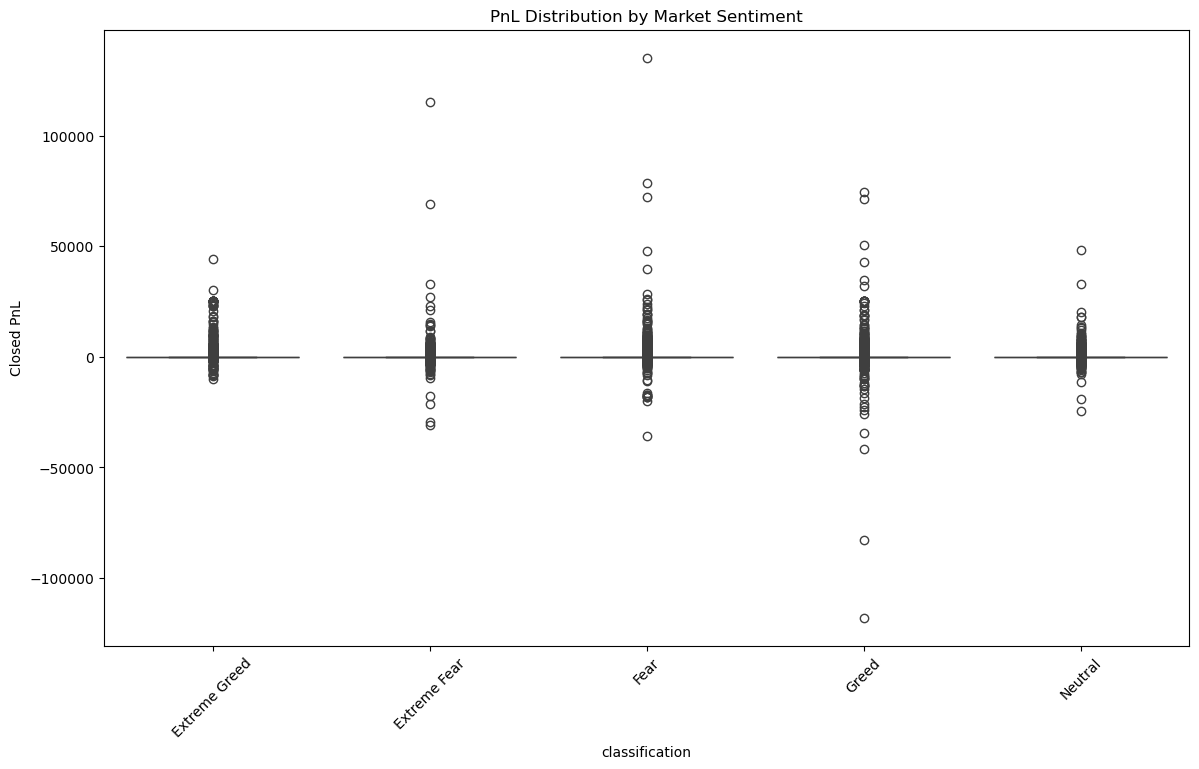

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=45)

plt.show()

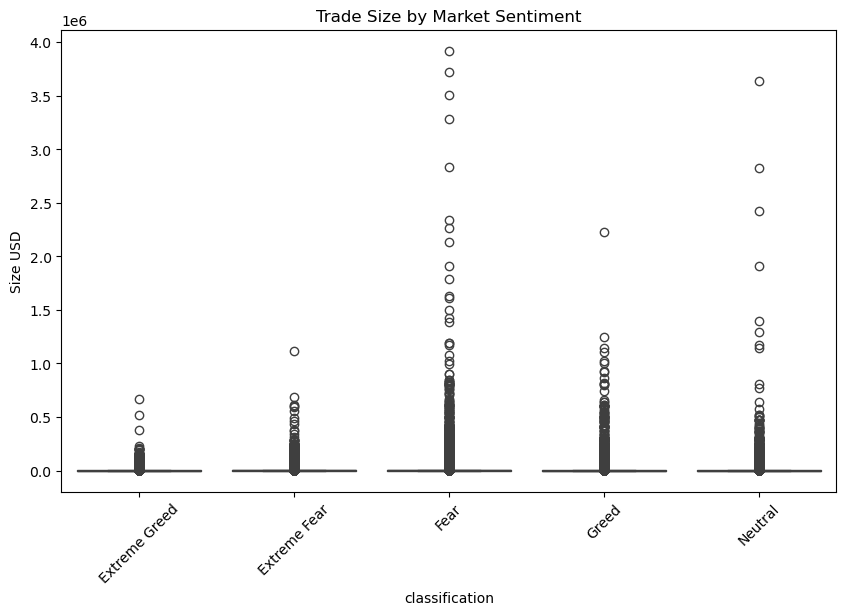

In [210]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='classification',
    y='Size USD',
    data=merged
)

plt.title("Trade Size by Market Sentiment")
plt.xticks(rotation=45)

plt.show()

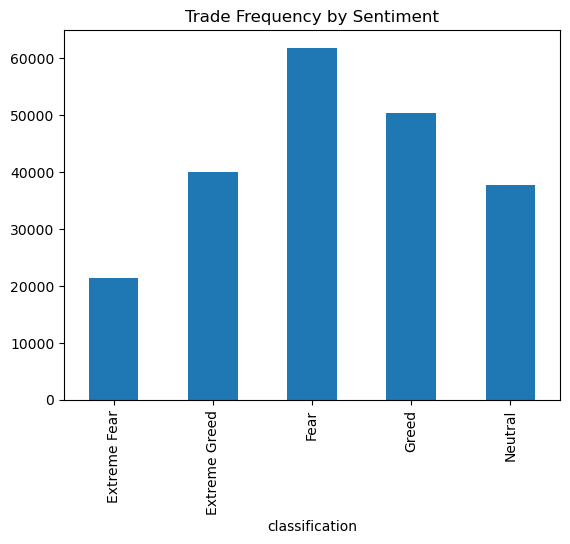

In [211]:
trade_freq = merged.groupby('classification').size()

trade_freq.plot(kind='bar')

plt.title("Trade Frequency by Sentiment")

plt.show()

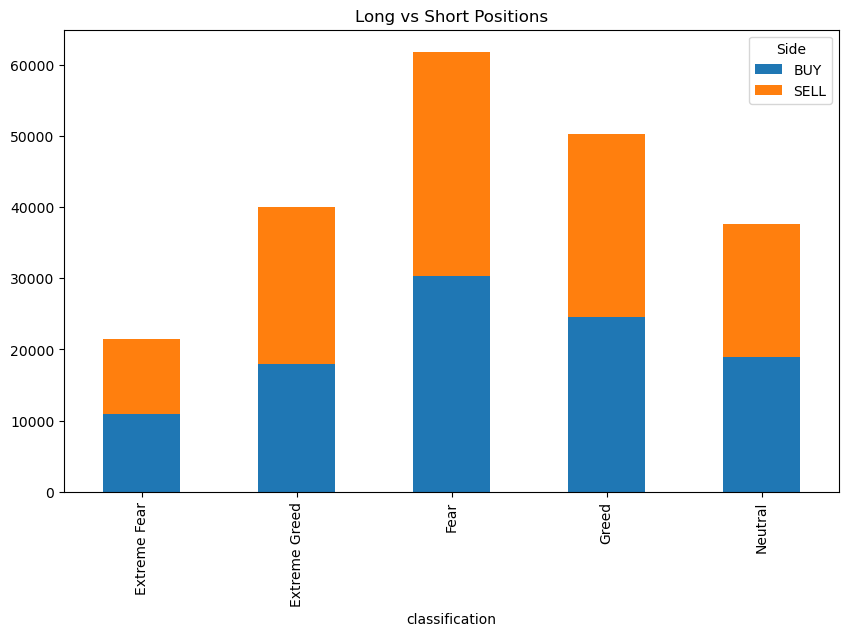

In [212]:
side_counts = merged.groupby(['classification', 'Side']).size().unstack()

side_counts.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Long vs Short Positions")

plt.show()

In [213]:
median_size = merged['Size USD'].median()

merged['Trader Segment'] = merged['Size USD'].apply(
    lambda x: 'High Size Trader' if x > median_size else 'Low Size Trader'
)

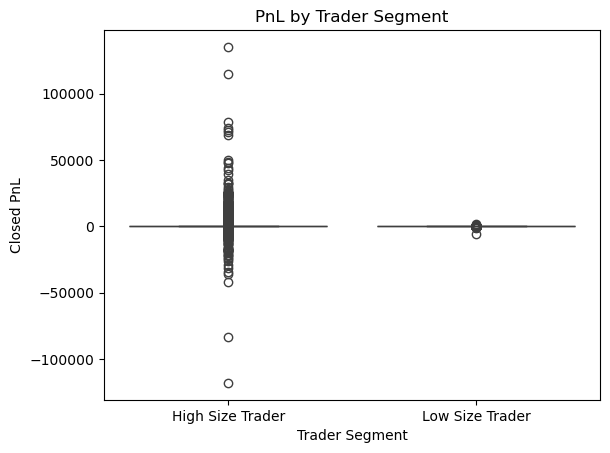

In [214]:
sns.boxplot(
    x='Trader Segment',
    y='Closed PnL',
    data=merged
)

plt.title("PnL by Trader Segment")

plt.show()

In [215]:
threshold = merged['Closed PnL'].median()

merged['profitability'] = merged['Closed PnL'].apply(
    lambda x: 1 if x > threshold else 0
)

In [216]:
merged.columns = merged.columns.str.strip()

In [217]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

merged['classification_encoded'] = encoder.fit_transform(
    merged['classification']
)

features['classification_encoded'] = merged['classification_encoded']

In [218]:
features = merged[[
    'Size USD',
    'Fee',
    'Execution Price',
    'classification_encoded'
]]

target = merged['profitability']

In [219]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [220]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=20,
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [221]:


import joblib

joblib.dump(model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [222]:
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [223]:
predictions = model.predict(X_test)

In [224]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5814790266073289


# **CLUSTERING TRADERES**

In [225]:
trader_features = merged.groupby('Account').agg({
    'Size USD': 'mean',
    'Closed PnL': 'mean',
    'Fee': 'mean'
}).reset_index()

In [226]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(
    trader_features[['Size USD', 'Closed PnL', 'Fee']]
)

In [227]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

trader_features['cluster'] = kmeans.fit_predict(scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


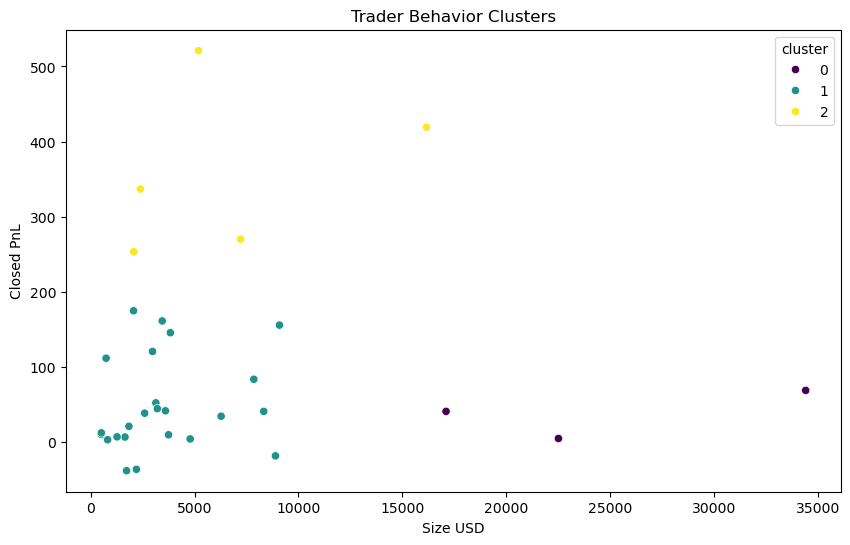

In [228]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=trader_features['Size USD'],
    y=trader_features['Closed PnL'],
    hue=trader_features['cluster'],
    palette='viridis'
)

plt.title("Trader Behavior Clusters")

plt.show()

In [229]:

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']



**Cluster 0 → Conservative Traders**

Cluster 1 → High-Risk Aggressive Traders  

Cluster 2 → Moderate Consistent Traders

